<a href="https://colab.research.google.com/github/nexageapps/AI/blob/main/Basic/B04%20-%20Multi-Class%20Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 4: Multi-Class Classification with Softmax

**MAI Alignment:** COMPSCI 714 (Lecture 2), COMPSCI 762 | **Next Level:** [I05 - Transfer Learning](../Intermediate/I05%20-%20Transfer%20Learning%20and%20Fine-tuning.ipynb)


## Learning Objectives
- Understand multi-class classification vs binary classification
- Learn about softmax activation function
- Implement categorical cross-entropy loss
- Build a model to classify handwritten digits (MNIST)

## Prerequisites
- Completed L1-L4
- Understanding of binary classification
- Basic neural network concepts

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

2026-05-21 12:09:53.853824: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2


## 1. Understanding Multi-Class Classification

In binary classification (L3), we had 2 classes (Pass/Fail).  
In multi-class classification, we have 3 or more classes.

**Example:** Classifying handwritten digits (0-9) = 10 classes

### Key Differences:
- **Output Layer:** Instead of 1 neuron, we need N neurons (one per class)
- **Activation:** Softmax instead of Sigmoid
- **Loss:** Categorical Cross-Entropy instead of Binary Cross-Entropy

## 2. Load and Explore MNIST Dataset

MNIST contains 70,000 images of handwritten digits (0-9)  
- Training: 60,000 images
- Testing: 10,000 images
- Image size: 28x28 pixels (grayscale)

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"\nPixel value range: {x_train.min()} to {x_train.max()}")
print(f"Unique labels: {np.unique(y_train)}")

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)

Pixel value range: 0 to 255
Unique labels: [0 1 2 3 4 5 6 7 8 9]


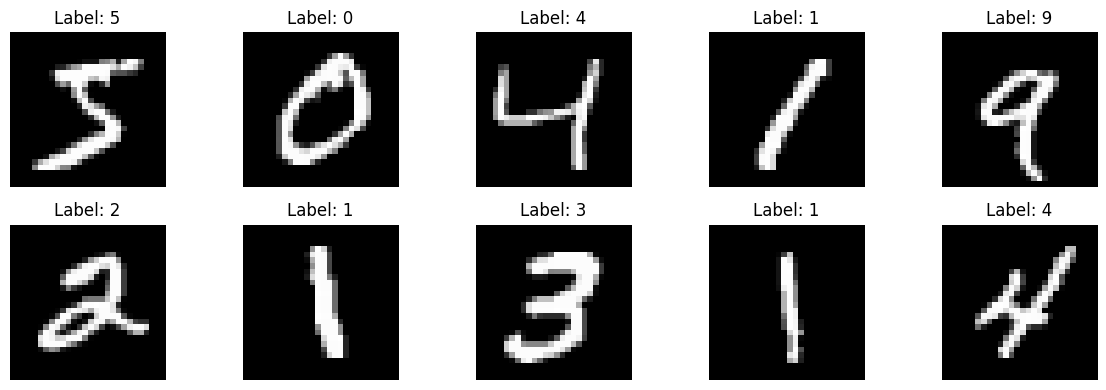

In [3]:
# Visualize some examples
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='grey')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

We need to:
1. Normalize pixel values (0-255) to (0-1)
2. Flatten 28x28 images to 784-dimensional vectors
3. Convert labels to one-hot encoding

In [4]:
# Normalize pixel values to 0-1 range
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

# Flatten images from 28x28 to 784
x_train_flat = x_train_normalized.reshape(-1, 784)
x_test_flat = x_test_normalized.reshape(-1, 784)

print(f"Flattened training data shape: {x_train_flat.shape}")
print(f"Flattened test data shape: {x_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [5]:
# Convert labels to one-hot encoding
# Example: 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_onehot = keras.utils.to_categorical(y_train, 10)
y_test_onehot = keras.utils.to_categorical(y_test, 10)

print(f"Original label: {y_train[0]}")
print(f"One-hot encoded: {y_train_onehot[0]}")
print(f"\nOne-hot shape: {y_train_onehot.shape}")

Original label: 5
One-hot encoded: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

One-hot shape: (60000, 10)


## 4. Understanding Softmax Activation

**Softmax** converts raw scores (logits) into probabilities that sum to 1.

Formula: `softmax(x_i) = exp(x_i) / sum(exp(x_j))`

**Why Softmax?**
- Outputs are interpretable as probabilities
- All outputs sum to 1
- Emphasizes the largest value (winner-takes-all)

Logits (raw scores): [2.  1.  0.1 3.  0.5]
Softmax probabilities: [0.22427257 0.08250527 0.03354414 0.60963605 0.05004197]
Sum of probabilities: 1.0000
Predicted class: 3


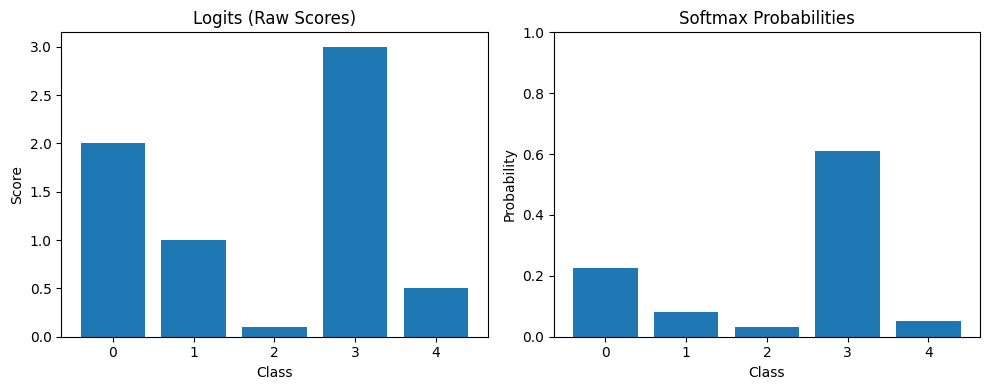

In [6]:
# Demonstrate softmax
def softmax_demo(logits):
    exp_logits = np.exp(logits)
    probabilities = exp_logits / np.sum(exp_logits)
    return probabilities

# Example logits (raw scores from network)
logits = np.array([2.0, 1.0, 0.1, 3.0, 0.5])
probs = softmax_demo(logits)

print("Logits (raw scores):", logits)
print("Softmax probabilities:", probs)
print(f"Sum of probabilities: {probs.sum():.4f}")
print(f"Predicted class: {np.argmax(probs)}")

# Visualize
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(len(logits)), logits)
plt.title('Logits (Raw Scores)')
plt.xlabel('Class')
plt.ylabel('Score')

plt.subplot(1, 2, 2)
plt.bar(range(len(probs)), probs)
plt.title('Softmax Probabilities')
plt.xlabel('Class')
plt.ylabel('Probability')
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

## 5. Build Multi-Class Classification Model

Architecture:
- Input: 784 features (28x28 flattened)
- Output: 10 neurons (one per digit)
- Activation: Softmax
- Loss: Categorical Cross-Entropy

In [7]:
# Build the model
model = keras.Sequential([
    layers.Dense(10, activation='softmax', input_shape=(784,))
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/Users/arjunkarthik/Applications/MAI/AI/AI/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

In [8]:
# Train the model
history = model.fit(
    x_train_flat, 
    y_train_onehot,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8153 - loss: 0.7410 - val_accuracy: 0.8958 - val_loss: 0.4088
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8969 - loss: 0.3889 - val_accuracy: 0.9083 - val_loss: 0.3351
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9076 - loss: 0.3380 - val_accuracy: 0.9162 - val_loss: 0.3070
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9130 - loss: 0.3140 - val_accuracy: 0.9177 - val_loss: 0.2950
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9167 - loss: 0.2999 - val_accuracy: 0.9218 - val_loss: 0.2870
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9189 - loss: 0.2903 - val_accuracy: 0.9218 - val_loss: 0.2797
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9212 - loss: 0.2836 - val_accuracy: 0.9248 - val_loss: 0.2735
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9224 - loss: 0.2780 - val_accuracy: 0.

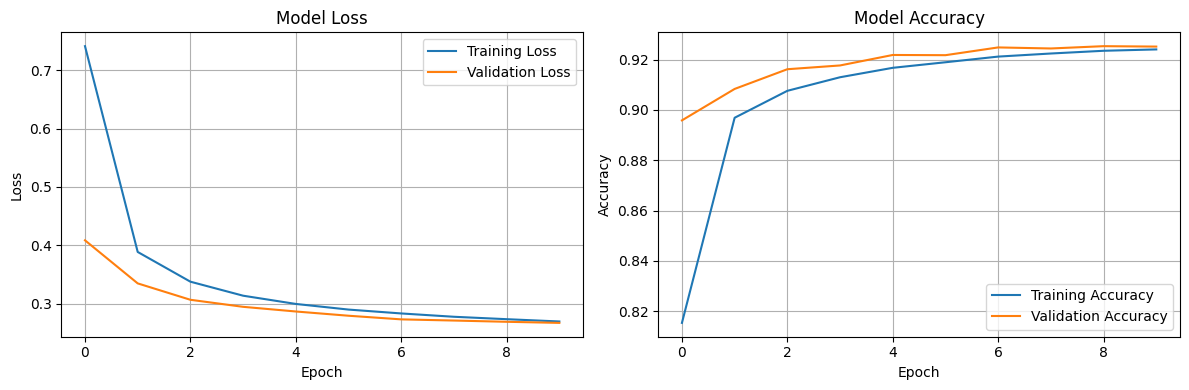

In [9]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluate the Model

In [10]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test_onehot, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 92.41%
Test Loss: 0.2709


## 8. Make Predictions and Visualize Results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


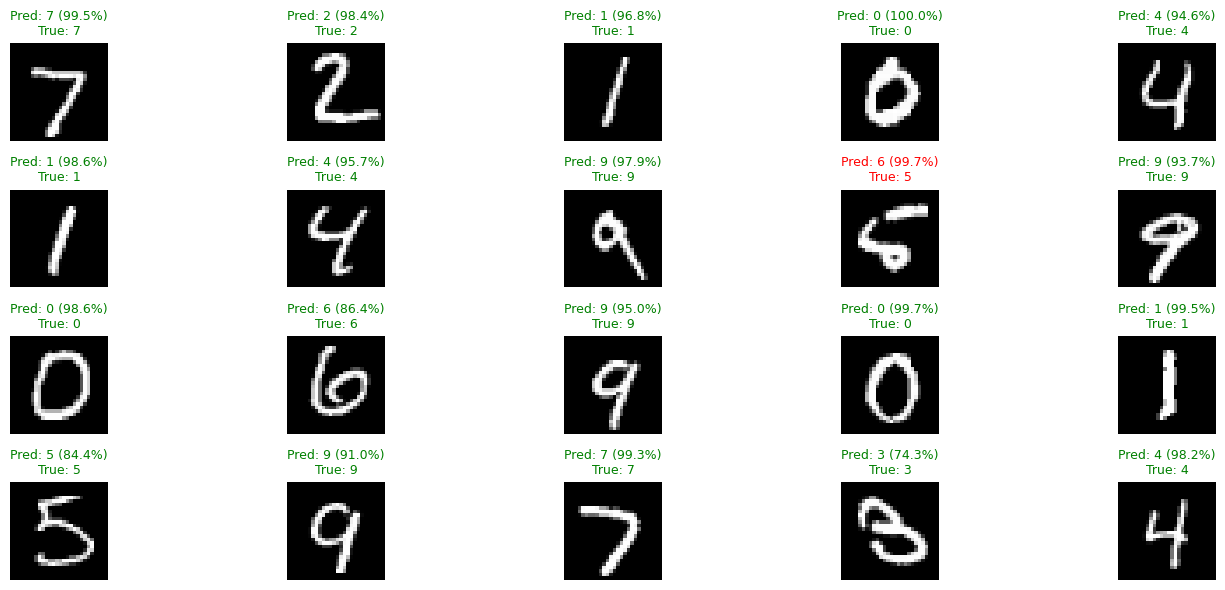

In [11]:
# Make predictions on test set
predictions = model.predict(x_test_flat[:20])

# Visualize predictions
plt.figure(figsize=(15, 6))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    
    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]
    confidence = predictions[i][predicted_label] * 100
    
    color = 'green' if predicted_label == true_label else 'red'
    plt.title(f"Pred: {predicted_label} ({confidence:.1f}%)\nTrue: {true_label}", 
              color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 9. Confusion Matrix

A confusion matrix shows which classes are being confused with each other.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


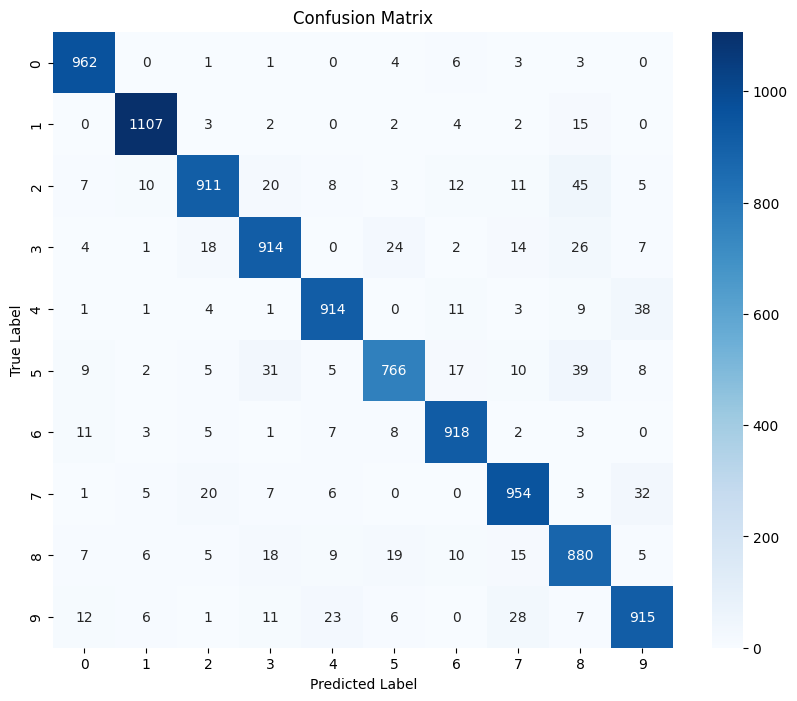


Per-class Accuracy:
Digit 0: 98.16%
Digit 1: 97.53%
Digit 2: 88.28%
Digit 3: 90.50%
Digit 4: 93.08%
Digit 5: 85.87%
Digit 6: 95.82%
Digit 7: 92.80%
Digit 8: 90.35%
Digit 9: 90.68%


In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
#Install: pip install scikit-learn

# Get predictions for all test data
y_pred = np.argmax(model.predict(x_test_flat), axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print per-class accuracy
print("\nPer-class Accuracy:")
for i in range(10):
    class_accuracy = cm[i, i] / cm[i].sum() * 100
    print(f"Digit {i}: {class_accuracy:.2f}%")

## 10. Key Takeaways

1. **Multi-class classification** extends binary classification to multiple classes
2. **Softmax** converts logits to probabilities that sum to 1
3. **One-hot encoding** represents categorical labels as binary vectors
4. **Categorical cross-entropy** is the standard loss for multi-class problems
5. **Confusion matrix** helps identify which classes are being confused

## Next Steps (L6)
- Add hidden layers to improve accuracy
- Learn about activation functions (ReLU, tanh)
- Understand overfitting and regularization

## References
- MNIST Dataset: http://yann.lecun.com/exdb/mnist/
- Softmax Function: https://en.wikipedia.org/wiki/Softmax_function
- TensorFlow Documentation: https://www.tensorflow.org/

---

## Exercises

Test your understanding with these hands-on exercises. Try to solve them before looking at the hints.


### Exercise 1: Softmax by Hand

Implement the softmax function from scratch using NumPy. Given the logits `[2.0, 1.0, 0.1]`, compute the softmax probabilities manually and verify they sum to 1.0. Then compare your result with `tf.nn.softmax`.



In [ ]:
import numpy as np

def softmax(logits):
    """Compute softmax: softmax(z_i) = e^(z_i) / Σ e^(z_j)"""
    # Your code here
    pass

# Test
logits = [2.0, 1.0, 0.1]
# probs = softmax(logits)
# print(f"Probabilities: {probs}")
# print(f"Sum: {sum(probs):.4f}")  # Should be 1.0


### Exercise 2: Fashion MNIST Classifier

Replace the MNIST digit dataset with **Fashion MNIST** (`tf.keras.datasets.fashion_mnist`). Build and train a multi-class classifier to recognize clothing items (T-shirt, trouser, pullover, etc.). Compare the accuracy with the digit classifier.



In [ ]:
# Fashion MNIST has the same shape as MNIST (28x28 grayscale)
# but classifies 10 clothing categories instead of digits

# (X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
#                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Your code here: normalize, build model, train, evaluate


---

## Key Takeaways

**Relevant UoA Courses:** COMPSCI 762, COMPSCI 713, COMPSCI 761

1. Softmax converts logits to probability distribution: p_i = e^(z_i) / Σe^(z_j)
2. Categorical cross-entropy: L = -Σ y_i·log(p_i) where y is one-hot encoded
3. One-hot encoding represents class k as vector with 1 at position k, 0 elsewhere
4. Output layer has one neuron per class
5. Softmax ensures all probabilities sum to 1

---

## Exam Preparation Guide

### Essential Concepts for Exams

- Understand softmax properties: outputs sum to 1, all values in (0,1)
- Know how to convert between class labels, one-hot, and probabilities
- Calculate softmax output given logits: [2.0, 1.0, 0.1]
- Explain why softmax is used instead of multiple sigmoids
- Common question: Given 10 classes, what's the output layer shape?

### Common Mistakes to Avoid

- ❌ Forgetting to one-hot encode labels
- ❌ Using sigmoid instead of softmax for multi-class
- ❌ Not understanding that softmax is over all classes simultaneously

### Practice Problems

1. Given logits [2, 1, 0], calculate softmax probabilities
2. Convert class label 3 (out of 5 classes) to one-hot encoding
3. Why does softmax(z + c) = softmax(z) for any constant c?

### How This Helps Your UoA Courses

**COMPSCI 762, COMPSCI 713, COMPSCI 761:**
- Provides hands-on implementation of theoretical concepts
- Practice problems similar to exam questions
- Reinforces lecture material with code examples
- Helps build intuition for complex topics

### Study Tips

1. **Understand, Don't Memorize**: Focus on why, not just what
2. **Practice Calculations**: Work through problems by hand
3. **Connect to Theory**: Link code to mathematical formulations
4. **Teach Others**: Explaining concepts solidifies understanding
5. **Review Regularly**: Spaced repetition improves retention

### Exam Question Types

- **Conceptual**: Explain why/how something works
- **Calculation**: Compute outputs, gradients, shapes
- **Comparison**: Compare approaches, trade-offs
- **Application**: Design solution for given problem
- **Debugging**: Identify and fix issues

---


---

## Learning Progress Tracker

Use this section to track your learning progress for this lesson.

### Completion Status
- [ ] Lesson completed
- [ ] All code cells executed successfully
- [ ] Understood all key concepts
- [ ] Completed practice exercises (if any)

### Dates
- **First Completed:** ____/____/____
- **Last Reviewed:** ____/____/____
- **Next Review:** ____/____/____ (Recommended: 1 week, 1 month, 3 months)

### Understanding Level
Rate your understanding (1-5): _____ / 5

- 1 = Need to review completely
- 2 = Understood basics, need more practice
- 3 = Good understanding, minor gaps
- 4 = Strong understanding, can explain to others
- 5 = Mastered, can apply in projects

### Notes & Reflections
```
Write your notes here:
- What concepts were challenging?
- What was interesting or surprising?
- How can you apply this in projects?
- Questions to explore further?




```

### Key Concepts to Remember (B04)
- [ ] Multi-class classification
- [ ] Softmax activation function
- [ ] Categorical cross-entropy
- [ ] One-hot encoding

---